In [ ]:
import numpy as np
import cv2
import networkx as nx
from google.colab.patches import cv2_imshow

148 148


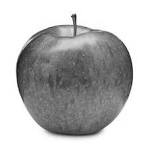

In [ ]:
# Load the image
img = cv2.imread('/content/apple.jpeg', 0)  #load image in grayscale
# img = cv2.resize(img, (220, 280))
(height,width)= img.shape
print(height, width)
cv2_imshow(img)

In [ ]:
# dilate mask and get inner and outer boundary of contour
def get_coord(mask, iterations):

  kernel = np.ones((3,3), np.uint8)

  # find dilated image
  dilated = cv2.dilate(mask, kernel, iterations=iterations)
  # cv2_imshow(dilated)

  # find the boundaries
  eroded= cv2.erode(dilated, kernel, iterations=1)
  final= dilated-eroded
  # cv2_imshow(final)

  contours, hierarchy = cv2.findContours(final.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
  # contours = contours[::-1]
  # hierarchy = hierarchy[::-1]

  # find inner and outer contours
  outer_contours = []
  inner_contours = []

  outer=[]
  inner=[]

  mx=-1
  for i in hierarchy[0]:
    mx= max(mx, i[3])

  for i, contour in enumerate(contours):
    #print(hierarchy[0][i][3])
    # Check the hierarchy to classify contours
    if hierarchy[0][i][3] == -1 and len(outer)==0:  # Outer contour (no parent)
      outer_contours.append(contour)
      for point in contour:
        x, y = point[0]  # Extracting x and y from point
        outer.append([y,x])
    elif hierarchy[0][i][3] == mx:  # Inner contour (has a parent)
      inner_contours.append(contour)
      for point in contour:
        x, y = point[0]  # Extracting x and y from point
        inner.append([y,x])

  # output_image = np.zeros_like(mask)
  # for p in outer:
  #   output_image[p[0],p[1]]=255
  # cv2_imshow(output_image)
  # for p in inner:
  #   output_image[p[0],p[1]]=255
  # cv2_imshow(output_image)

  # find all points which are white
  white = np.column_stack(np.where(dilated == 255)).tolist()

  return white, outer, inner


In [ ]:
# allnodes,source,sink= get_coord(mask, 3)

In [ ]:
# Create graph

# create custom weight function
def get_weight(img, lst1, lst2):
  weight = 1 / (1 + abs(int(img[lst1[0], lst1[1]]) - int(img[lst2[0], lst2[1]])))
  return weight

def get_graph(node_map):
  G = nx.Graph()

  # Define 8-connectivity for neighboring pixels
  for x in range(height):
    for y in range(width):

      if node_map.get(str([x,y])) == None:
        continue

      if x < height - 1: # down node
        next= [x+1,y]
        b= (node_map.get(str(next)) == None) or (node_map[str([x,y])] == "source" and node_map[str(next)] == "source") or (node_map[str([x,y])] == "sink" and node_map[str(next)] == "sink")
        if b == False:
          weight = get_weight(img, [x,y], next)
          G.add_edge(node_map[str([x,y])], node_map[str(next)], capacity= weight)

      if y < width - 1: # right node
        next= [x,y+1]
        b= (node_map.get(str(next)) == None) or (node_map[str([x,y])] == "source" and node_map[str(next)] == "source") or (node_map[str([x,y])] == "sink" and node_map[str(next)] == "sink")
        if b == False:
          weight = get_weight(img, [x,y], next)
          G.add_edge(node_map[str([x,y])], node_map[str(next)], capacity= weight)


      if x < height - 1 and y < width -1 : # down-right node
        next= [x+1,y+1]
        b= (node_map.get(str(next)) == None) or (node_map[str([x,y])] == "source" and node_map[str(next)] == "source") or (node_map[str([x,y])] == "sink" and node_map[str(next)] == "sink")
        if b == False:
          weight = get_weight(img, [x,y], next)
          G.add_edge(node_map[str([x,y])], node_map[str(next)], capacity= weight)


      if x > 0 and y < width-1: # top-right node
        next= [x-1,y+1]
        b= (node_map.get(str(next)) == None) or (node_map[str([x,y])] == "source" and node_map[str(next)] == "source") or (node_map[str([x,y])] == "sink" and node_map[str(next)] == "sink")
        if b == False:
          weight = get_weight(img, [x,y], next)
          G.add_edge(node_map[str([x,y])], node_map[str(next)], capacity= weight)

# See graph adjacency list
# G.adj
  return G


In [ ]:
def get_cut(G):
  cut_value, partition = nx.minimum_cut(G, "source", "sink")
  reachable, non_reachable = partition
  cutset = set()
  for u, nbrs in ((n, G[n]) for n in reachable):
    cutset.update((u, v) for v in nbrs if v in non_reachable)

  return cutset

In [ ]:
def nearest_source(a, node_map):
  dx= [-1, -1, -1, 0, 0, 1, 1, 1]
  dy= [-1, 0, 1, -1, 1, -1, 0, 1]
  for k in range(8):
    x= a[0]+ dx[k]
    y= a[1]+ dy[k]
    if node_map.get(str([x,y])) != None and node_map[str([x,y])]=="source":
      return (x,y)

  return None

def get_nextmask(cutset, node_map):
  contour_image = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
  next_mask = np.zeros_like(img)

  for [a,b] in cutset:
    if a == "source":
      x,y= nearest_source(b, node_map)
      next_mask[x,y]=255
      contour_image[x,y]= (0, 255, 0)
    else:
      next_mask[a[0], a[1]]=255
      contour_image[a[0],a[1]]= (0, 255, 0)

  return next_mask,contour_image

In [ ]:
'''
try with 50 and 60 for apple
and (30,20) and (260, 150) with car
(50,10), (160,220) for doll
(10,10), (240,250) for broken square
try with 60 for concave square
'''

'\ntry with 50 and 60 for apple\nand (30,20) and (260, 150) with car\n(50,10), (160,220) for doll\n(10,10), (240,250) for broken square\ntry with 60 for concave square\n'

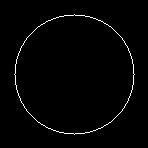

In [ ]:
# Initial binary mask (user-provided or from an edge detector)
mask = np.zeros_like(img)
mask= cv2.circle(mask, (width//2, height//2),60, 255, 1)
#mask= cv2.rectangle(mask, (30,40), (200,220), 255, 1)
cv2_imshow(mask)

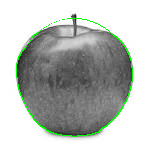

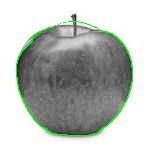

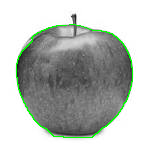

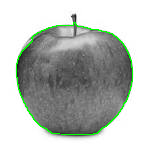

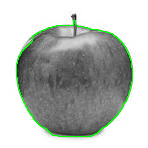

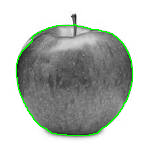

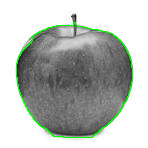

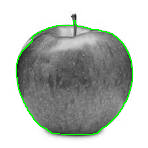

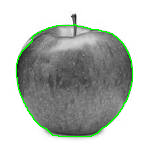

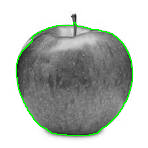

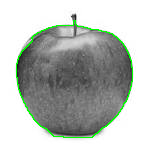

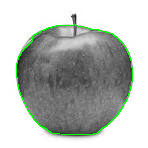

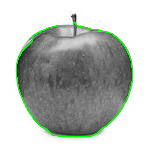

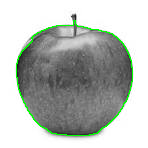

KeyboardInterrupt: 

In [ ]:
for i in range(20):
  allnodes,sink,source= get_coord(mask, 3)
  node_map={}
  for node in allnodes:
    node_map[str(node)]= (node[0], node[1])

  for node in source:
    node_map[str(node)]= "source"

  for node in sink:
    node_map[str(node)]= "sink"

  G= get_graph(node_map)
  cutset= get_cut(G)
  mask,contour_image= get_nextmask(cutset, node_map)
  cv2_imshow(contour_image)

In [ ]:
cv2.waitKey(0)
cv2.destroyAllWindows()